# 🚑 Riyadh Emergency Access - MVP

Ask a planning question in plain language. Three agents answer it, all as nodes in one LangGraph graph:

```
START ──▶ planner ──▶ graph_analyst ──▶ loop_guard ──▶ writer ──▶ END
             │            ▲      ▲          │
             │            │      └─ retry ──┤
             │            └──── tools ◀─────┘   (critical_roads, suggest_new_sites)
             └──▶ END   (question out of scope)
```

* **planner** checks the question is about emergency access in Riyadh; if not, it ends early with a short reply.
* **graph_analyst** calls the graph tools on Riyadh's real road network, looping through the **tools** node until it has its findings.
* **loop_guard** checks every tool request: step budgets, plus a **LoopDetector** for repeated calls (retry) and calls that return nothing new (warn).
* **writer** turns the findings into a short report for a city planner.

Every model call and tool call is a separate step, so `ask()` can print them as they happen.

## 1. Setup

In [2]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
import json
import os
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
from langchain_google_genai import ChatGoogleGenerativeAI

CENTER = (24.7136, 46.6753)
RADIUS_M = 10_000
DEFAULT_THRESHOLD_MIN = 10
CACHE_DIR = Path('cache')

MODEL_NAME = 'gemini-3-flash-preview'

api_key = os.environ['AI_API_KEY']

# Native Gemini client: it keeps the thought signatures Gemini 3 requires on tool calls
llm = ChatGoogleGenerativeAI(model=MODEL_NAME, google_api_key=api_key)

## 2. Data: road network and hospitals
Roads become a directed graph (intersections = nodes, road segments = edges weighted by travel time in seconds).
Hospitals come from OpenStreetMap (`amenity=hospital`). The first run downloads for a few minutes; later runs use the cache.

In [5]:
import osmnx as ox


def load_data():
    CACHE_DIR.mkdir(exist_ok=True)
    graph_file = CACHE_DIR / f'roads_{RADIUS_M}.graphml'
    hosp_file = CACHE_DIR / f'hospitals_{RADIUS_M}.csv'
    if graph_file.exists() and hosp_file.exists():
        return ox.load_graphml(graph_file), pd.read_csv(hosp_file)

    G = ox.graph_from_point(CENTER, dist=RADIUS_M, network_type='drive')
    G = ox.truncate.largest_component(G, strongly=True)
    G = ox.routing.add_edge_speeds(G)
    G = ox.routing.add_edge_travel_times(G)

    gdf = ox.features_from_point(CENTER, tags={'amenity': 'hospital'}, dist=RADIUS_M)
    pts = gdf.geometry.representative_point()
    names = gdf['name'] if 'name' in gdf.columns else pd.Series('Unnamed hospital', index=gdf.index)
    hospitals = pd.DataFrame({'name': names.fillna('Unnamed hospital').values,
                              'lat': pts.y.values, 'lon': pts.x.values})
    hospitals['node'] = ox.distance.nearest_nodes(G, X=hospitals.lon.values, Y=hospitals.lat.values)
    hospitals = hospitals.drop_duplicates('node').reset_index(drop=True)

    ox.save_graphml(G, graph_file)
    hospitals.to_csv(hosp_file, index=False)
    return G, hospitals


G, hospitals = load_data()
print(f'{len(G):,} road locations, {G.number_of_edges():,} road segments, {len(hospitals)} hospitals')

45,766 road locations, 117,905 road segments, 60 hospitals


In [6]:
def precompute_access(G, hospital_nodes):
    R = G.reverse(copy=True)
    R.add_node('SUPER')
    for h in hospital_nodes:
        R.add_edge('SUPER', h, travel_time=0.0)
    pred, dist = nx.dijkstra_predecessor_and_distance(R, 'SUPER', weight='travel_time')
    dist.pop('SUPER')
    next_hop = {v: p[0] for v, p in pred.items() if p and p[0] != 'SUPER'}
    return dist, next_hop


def road_name(G, u, v):
    data = min(G.get_edge_data(u, v).values(), key=lambda e: e.get('travel_time', 1e9))
    name = data.get('name')
    return ' / '.join(name) if isinstance(name, list) else name


def coverage_pct(dist, threshold_s):
    return round(100 * float((np.array(list(dist.values())) <= threshold_s).mean()), 1)


DIST, NEXT_HOP = precompute_access(G, hospitals['node'].tolist())
for m in (5, 10, 15):
    print(f'Within {m:>2} min of a hospital: {coverage_pct(DIST, m * 60)}%')

Within  5 min of a hospital: 89.7%
Within 10 min of a hospital: 99.6%
Within 15 min of a hospital: 100.0%


In [7]:
def critical_roads_impl(top_n=10):
    load = {v: 1 for v in DIST}
    road_load = {}
    for v in sorted(DIST, key=DIST.get, reverse=True):      # farthest first
        p = NEXT_HOP.get(v)
        if p is None:
            continue
        load[p] += load[v]
        name = road_name(G, v, p)
        if name and load[v] > road_load.get(name, (0,))[0]:
            road_load[name] = (load[v], v)
    ranked = sorted(road_load.items(), key=lambda kv: kv[1][0], reverse=True)[:top_n]
    return [{'road': name, 'share_of_area_pct': round(100 * n / len(DIST), 1),
             'lat': round(G.nodes[v]['y'], 5), 'lon': round(G.nodes[v]['x'], 5)}
            for name, (n, v) in ranked]


def suggest_sites_impl(k=3, threshold_minutes=DEFAULT_THRESHOLD_MIN, n_candidates=150):
    thr = threshold_minutes * 60
    uncovered = {v for v, t in DIST.items() if t > thr}
    result = {'threshold_minutes': threshold_minutes, 'coverage_before_pct': coverage_pct(DIST, thr), 'sites': []}
    if not uncovered:
        result['coverage_after_pct'] = result['coverage_before_pct']
        return result

    rng = np.random.default_rng(42)
    pool = list(uncovered)
    candidates = [pool[i] for i in rng.choice(len(pool), min(n_candidates, len(pool)), replace=False)]
    R = G.reverse(copy=False)
    reach = {c: set(nx.single_source_dijkstra_path_length(R, c, cutoff=thr, weight='travel_time'))
             for c in candidates}

    remaining = set(uncovered)
    for _ in range(k):
        best = max(candidates, key=lambda c: len(reach[c] & remaining))
        gained = reach[best] & remaining
        if not gained:
            break
        remaining -= gained
        candidates.remove(best)
        result['sites'].append({'lat': round(G.nodes[best]['y'], 5), 'lon': round(G.nodes[best]['x'], 5),
                                'newly_covered_pct': round(100 * len(gained) / len(DIST), 1)})
    result['coverage_after_pct'] = round(100 * (1 - len(remaining) / len(DIST)), 1)
    return result


print(json.dumps(critical_roads_impl(3), ensure_ascii=False, indent=2))
print(json.dumps(suggest_sites_impl(2, 5), indent=2))

[
  {
    "road": "الإنشراح",
    "share_of_area_pct": 4.5,
    "lat": 24.77943,
    "lon": 46.73882
  },
  {
    "road": "شارع خالد بن الوليد الفرعي",
    "share_of_area_pct": 4.5,
    "lat": 24.77904,
    "lon": 46.7379
  },
  {
    "road": "الظهيره",
    "share_of_area_pct": 4.3,
    "lat": 24.63258,
    "lon": 46.71152
  }
]
{
  "threshold_minutes": 5,
  "coverage_before_pct": 89.7,
  "sites": [
    {
      "lat": 24.63898,
      "lon": 46.58591,
      "newly_covered_pct": 1.8
    },
    {
      "lat": 24.7693,
      "lon": 46.76697,
      "newly_covered_pct": 1.6
    }
  ],
  "coverage_after_pct": 93.2
}


## 4. Tools
The docstring is what the model reads to decide when to call each tool.

In [8]:
from langchain_core.tools import tool


@tool
def critical_roads(top_n: int = 10) -> str:
    """Rank the roads that the most locations depend on to reach their nearest hospital.
    Returns JSON: road name, share of the area that depends on it (%), and a coordinate."""
    return json.dumps(critical_roads_impl(min(int(top_n), 25)), ensure_ascii=False)


@tool
def suggest_new_sites(k: int = 3, threshold_minutes: float = DEFAULT_THRESHOLD_MIN) -> str:
    """Recommend k sites for new emergency facilities that bring the most locations within
    `threshold_minutes` of driving. Returns coverage (%) before and after, and each site's coordinates."""
    return json.dumps(suggest_sites_impl(min(int(k), 10), float(threshold_minutes)))

## 5. Agents

In [9]:
from pydantic import BaseModel, Field

PLANNER_PROMPT = """You screen questions for a Riyadh emergency-access planning assistant.
The assistant can only answer questions about drive-time access to hospitals in Riyadh:
which roads matter most for reaching hospitals, how much of the city is within a drive time of care,
and where to add new emergency facilities to improve coverage.
Decide whether the question is in scope."""

EMERGENCY_ACCESS_ANALYST_PROMPT = """You analyze emergency access to hospitals in Riyadh using your tools.
Call the tools the question needs, then report the results.
If the question needs more than one tool, call them all together in a single response, not one after another.
Copy every number exactly as the tool returned it. Never invent or round numbers."""

WRITER_PROMPT = """You write a short Markdown report for a non-technical city planner with the headings
Summary, Findings, Recommendations, Limitations.
Use only the numbers in the findings, copied exactly. Give coordinates for any recommended site.
Mention that drive times assume no traffic."""


class RouteDecision(BaseModel):
    in_scope: bool = Field(description='True if the question is about emergency access to hospitals in Riyadh')
    reason: str = Field(description='One sentence explaining the decision, addressed to the user')


TOOLS = [critical_roads, suggest_new_sites]

planner = llm.with_structured_output(RouteDecision)
graph_analyst = llm.bind_tools(TOOLS)
writer = llm

## 6. LangGraph pipeline
Every tool request from the analyst passes through a **loop_guard** node before it runs. The guard:

* stops the analysis when a stage uses up its **step budget** (`STEP_BUDGET`),
* runs the **LoopDetector**, which spots two failure modes:
  * **repetition**: the analyst asks for a tool call (same tool, same arguments) it already made → the request is dropped and the analyst is **retried** with a warning,
  * **stagnation**: the last round of tool calls returned only results the analyst had already seen → the calls go ahead but the analyst is **warned**,
* after `MAX_LOOP_STRIKES` detections, stops the analysis and sends whatever results exist to the writer.

Warnings are printed as they happen and passed to the writer so the report's Limitations section mentions them.

In [10]:
STEP_BUDGET = {'graph_analyst': 4, 'tools': 3}   # max steps per stage in one run
MAX_LOOP_STRIKES = 2                              # loop detections before the analysis is stopped


class LoopDetector:
    """Checks the analyst's latest tool request against the conversation so far."""

    @staticmethod
    def _signature(call):
        return call['name'], json.dumps(call['args'], sort_keys=True)

    @staticmethod
    def _tool_rounds(messages):
        """Group tool results by the analyst turn that asked for them."""
        rounds = []
        for m in messages:
            if m.type == 'ai' and m.tool_calls:
                rounds.append([])
            elif m.type == 'tool' and rounds:
                rounds[-1].append(m.text)
        return rounds

    def check(self, messages):
        """Return (kind, detail) if the latest analyst turn is looping, else None."""
        *history, latest = messages
        past_calls = {self._signature(c) for m in history for c in getattr(m, 'tool_calls', [])}
        repeated = [c['name'] for c in latest.tool_calls if self._signature(c) in past_calls]
        if repeated:
            return 'repetition', f"{', '.join(repeated)} requested again with the same arguments"

        rounds = self._tool_rounds(history)
        if len(rounds) >= 2:
            seen = {text for r in rounds[:-1] for text in r}
            if all(text in seen for text in rounds[-1]):
                return 'stagnation', 'the last tool calls returned nothing new'
        return None


loop_detector = LoopDetector()

In [11]:
import operator
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import AnyMessage, HumanMessage, RemoveMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Command


def add_counts(a: dict, b: dict) -> dict:
    return {k: a.get(k, 0) + b.get(k, 0) for k in a.keys() | b.keys()}


class State(TypedDict):
    query: str
    in_scope: bool
    messages: Annotated[list[AnyMessage], add_messages]   # graph_analyst ⇄ tools conversation
    steps: Annotated[dict[str, int], add_counts]          # steps taken per stage
    warnings: Annotated[list[str], operator.add]          # loop detector and budget warnings
    loop_strikes: int
    report: str


def planner_node(state: State) -> dict:
    decision = planner.invoke([SystemMessage(PLANNER_PROMPT), HumanMessage(state['query'])])
    if decision.in_scope:
        return {'in_scope': True, 'messages': [HumanMessage(state['query'])]}
    return {'in_scope': False,
            'report': f"Sorry, I can't help with that. {decision.reason}\n\n"
                      'I can answer questions about emergency access to hospitals in Riyadh, such as which '
                      'roads matter most for reaching hospitals or where to add new emergency centers.'}


def route_after_planner(state: State) -> str:
    return 'graph_analyst' if state['in_scope'] else END


def graph_analyst_node(state: State) -> dict:
    system = EMERGENCY_ACCESS_ANALYST_PROMPT
    if state.get('warnings'):
        system += ('\n\nThe loop detector flagged these problems:\n' + '\n'.join(state['warnings']) +
                   '\nDo not repeat tool calls. If the results above answer the question, write your findings now.')
    response = graph_analyst.invoke([SystemMessage(system)] + state['messages'])
    return {'messages': [response], 'steps': {'graph_analyst': 1}}


def loop_guard_node(state: State) -> Command[Literal['tools', 'graph_analyst', 'writer']]:
    latest = state['messages'][-1]
    if not latest.tool_calls:
        return Command(goto='writer')

    for stage, budget in STEP_BUDGET.items():
        if state['steps'].get(stage, 0) >= budget:
            return Command(goto='writer', update={
                'warnings': [f'Step budget: {stage} used all {budget} steps, so the analysis was stopped early.']})

    loop = loop_detector.check(state['messages'])
    if loop is None:
        return Command(goto='tools')

    kind, detail = loop
    strikes = state.get('loop_strikes', 0) + 1
    if strikes >= MAX_LOOP_STRIKES:
        return Command(goto='writer', update={'loop_strikes': strikes, 'warnings': [
            f'LoopDetector ({kind}): {detail}. Strike {strikes}/{MAX_LOOP_STRIKES}, so the analysis was stopped.']})
    if kind == 'repetition':
        # Retry: drop the repeated request and ask the analyst again, with the warning in its prompt
        return Command(goto='graph_analyst', update={
            'loop_strikes': strikes, 'messages': [RemoveMessage(id=latest.id)],
            'warnings': [f'LoopDetector ({kind}): {detail}. Retrying the analyst.']})
    return Command(goto='tools', update={'loop_strikes': strikes, 'warnings': [
        f'LoopDetector ({kind}): {detail}. Warning the analyst.']})


tool_node = ToolNode(TOOLS)


def tools_node(state: State) -> dict:
    return {**tool_node.invoke(state), 'steps': {'tools': 1}}


def collect_findings(state: State) -> str:
    last = state['messages'][-1]
    if last.type == 'ai' and not last.tool_calls:
        return last.text
    # The analyst was stopped before it wrote findings, so pass on the raw tool results
    results = [f'{m.name}: {m.text}' for m in state['messages'] if m.type == 'tool']
    return 'The analysis was stopped before the analyst finished. Raw tool results:\n' + '\n'.join(results)


def writer_node(state: State) -> dict:
    prompt = f"QUESTION: {state['query']}\n\nFINDINGS:\n{collect_findings(state)}"
    if state.get('warnings'):
        prompt += '\n\nRUN WARNINGS (mention them under Limitations):\n' + '\n'.join(state['warnings'])
    response = writer.invoke([SystemMessage(WRITER_PROMPT), HumanMessage(prompt)])
    return {'report': response.text}


graph = StateGraph(State)
graph.add_node('planner', planner_node)
graph.add_node('graph_analyst', graph_analyst_node)
graph.add_node('loop_guard', loop_guard_node)
graph.add_node('tools', tools_node)
graph.add_node('writer', writer_node)
graph.add_edge(START, 'planner')
graph.add_conditional_edges('planner', route_after_planner, ['graph_analyst', END])
graph.add_edge('graph_analyst', 'loop_guard')   # loop_guard routes to tools, back to graph_analyst, or to writer
graph.add_edge('tools', 'graph_analyst')
graph.add_edge('writer', END)
pipeline = graph.compile()

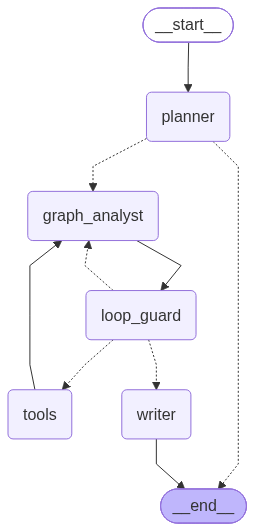

In [12]:
from IPython.display import Image, display

display(Image(pipeline.get_graph().draw_mermaid_png()))

## 7. Run it

In [13]:
from IPython.display import Markdown, display


def ask(question: str, verbose: bool = True) -> str:
    """Run the pipeline. With verbose=True, print each step (node, tool calls, tool results) as it happens.
    Loop detector and budget warnings are always printed."""
    report, steps = '', {}
    for chunk in pipeline.stream({'query': question}, stream_mode='updates'):
        for node, update in chunk.items():
            update = update or {}
            steps = add_counts(steps, update.get('steps', {}))
            if verbose and node != 'loop_guard':
                budget = f' (step {steps[node]}/{STEP_BUDGET[node]})' if node in STEP_BUDGET else ''
                print(f'▶ {node}{budget}')
                for msg in update.get('messages', []):
                    for call in getattr(msg, 'tool_calls', []):
                        print(f"    calls {call['name']}({call['args']})")
                    if msg.type == 'tool':
                        print(f'    {msg.name} returned {msg.text[:200]}')
            for warning in update.get('warnings', []):
                print(f'  ⚠ {warning}')
            report = update.get('report', report)
    display(Markdown(report))
    return report


ask('Where should Riyadh add 3 new emergency centers so more of the city is within 10 minutes of a hospital, '
    'and which 5 roads matter most for reaching hospitals?')

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


▶ planner
▶ graph_analyst (step 1/4)
    calls suggest_new_sites({'threshold_minutes': 10, 'k': 3})
    calls critical_roads({'top_n': 5})
▶ tools (step 1/3)
    suggest_new_sites returned {"threshold_minutes": 10.0, "coverage_before_pct": 99.6, "sites": [{"lat": 24.66108, "lon": 46.59404, "newly_covered_pct": 0.3}, {"lat": 24.64396, "lon": 46.63391, "newly_covered_pct": 0.1}, {"lat": 2
    critical_roads returned [{"road": "الإنشراح", "share_of_area_pct": 4.5, "lat": 24.77943, "lon": 46.73882}, {"road": "شارع خالد بن الوليد الفرعي", "share_of_area_pct": 4.5, "lat": 24.77904, "lon": 46.7379}, {"road": "الظهيره"
▶ graph_analyst (step 2/4)
▶ writer


# Emergency Access Expansion Report: Riyadh

### Summary
This report identifies optimal locations for three new emergency centers to achieve total coverage within the city of Riyadh. It also highlights the five road segments most critical for ensuring residents can reach medical facilities within a 10-minute window.

### Findings
The analysis shows that Riyadh currently has 99.6% coverage. By adding three strategic emergency centers, this can be increased to 100%. The following roads represent the highest share of the area depending on them for hospital access:

1.  **الإنشراح**: 4.5% of the area
2.  **شارع خالد بن الوليد الفرعي**: 4.5% of the area
3.  **الظهيره**: 4.3% of the area
4.  **الفواز**: 4% of the area
5.  **الشيخ عبدالله العنقري**: 3.8% of the area

Regarding the proposed expansion sites:
*   **Site 1** covers an additional 0.3% of the area.
*   **Site 2** covers an additional 0.1% of the area.
*   **Site 3** covers an additional 0% of the area.

### Recommendations
To reach the goal of 100% coverage, it is recommended to establish emergency centers at the following coordinates:
*   **Site 1:** (24.66108, 46.59404)
*   **Site 2:** (24.64396, 46.63391)
*   **Site 3:** (24.64229, 46.61074)

Additionally, city planning should prioritize traffic flow and infrastructure maintenance on the five critical roads listed in the findings to prevent a decrease in emergency response efficiency.

### Limitations
The analysis and suggested drive times assume no traffic. Actual response times may vary based on congestion, time of day, and road conditions.

'# Emergency Access Expansion Report: Riyadh\n\n### Summary\nThis report identifies optimal locations for three new emergency centers to achieve total coverage within the city of Riyadh. It also highlights the five road segments most critical for ensuring residents can reach medical facilities within a 10-minute window.\n\n### Findings\nThe analysis shows that Riyadh currently has 99.6% coverage. By adding three strategic emergency centers, this can be increased to 100%. The following roads represent the highest share of the area depending on them for hospital access:\n\n1.  **الإنشراح**: 4.5% of the area\n2.  **شارع خالد بن الوليد الفرعي**: 4.5% of the area\n3.  **الظهيره**: 4.3% of the area\n4.  **الفواز**: 4% of the area\n5.  **الشيخ عبدالله العنقري**: 3.8% of the area\n\nRegarding the proposed expansion sites:\n*   **Site 1** covers an additional 0.3% of the area.\n*   **Site 2** covers an additional 0.1% of the area.\n*   **Site 3** covers an additional 0% of the area.\n\n### Reco


## 8. Map

🔴 hospitals · 🟠 critical roads · 🟢 suggested sites

In [ ]:
import folium

m = folium.Map(location=CENTER, zoom_start=12)
for _, h in hospitals.iterrows():
    folium.CircleMarker([h.lat, h.lon], radius=5, color='red', fill=True, tooltip=h['name']).add_to(m)
for r in critical_roads_impl(5):
    folium.Marker([r['lat'], r['lon']], icon=folium.Icon(color='orange'), tooltip=r['road']).add_to(m)
for s in suggest_sites_impl(3)['sites']:
    folium.Marker([s['lat'], s['lon']], icon=folium.Icon(color='green'), tooltip='Suggested site').add_to(m)
m